In [3]:
import pandas as pd
import numpy as np
import scipy as sp

from sklearn.datasets import fetch_openml
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import cross_val_predict, train_test_split
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt

In [4]:
# Courses Packages
from DataVisualization import PlotConfusionMatrix, PlotLabelsHistogram, PlotMnistImages

In [24]:
seedNum = 512
np.random.seed(seedNum)

numImg = 3
vSize = [28, 28] #Size of images

numSamples = 10_000
train_ratio = 0.55
test_ratio = 1 - train_ratio

In [6]:
# Loading of Data
mX, vY = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')

In [13]:
# after loading the values of vY are string, need toconvert them to integers
vY = vY.astype(np.int_)
print(f"Feature matrix data shape: {mX.shape}")
print(f"The labels datashape: {vY.shape}")
print(np.unique(vY, return_counts=True))

Feature matrix data shape: (70000, 784)
The labels datashape: (70000,)
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([6903, 7877, 6990, 7141, 6824, 6313, 6876, 7293, 6825, 6958]))


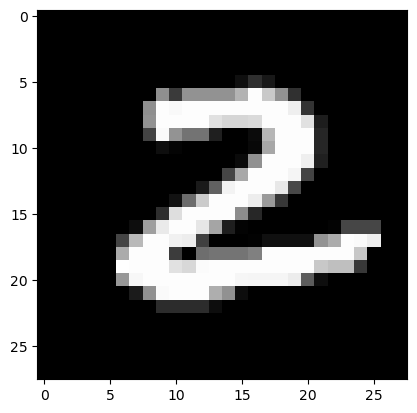

In [31]:
plt.imshow(mX[5].reshape(28, 28), cmap='gray') # visualization of the first row

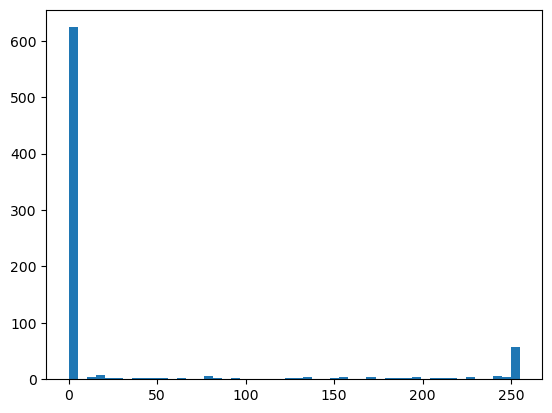

In [21]:
plt.hist(mX[0], bins = 50)
plt.show()

In [22]:
# Scaling of the values from [0, 255] to [0, 1]
mX = mX / 255

In [25]:
# sub sampling of data for the fast run

vSampleIdx = np.random.choice(mX.shape[0], numSamples, replace = False)
mX = mX[vSampleIdx, :]
vY = vY[vSampleIdx]

print(f"Feature matrix data shape: {mX.shape}")
print(f"The labels datashape: {vY.shape}")
print(np.unique(vY, return_counts=True))


Feature matrix data shape: (10000, 784)
The labels datashape: (10000,)
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([1001, 1201,  954,  995,  952,  862, 1010, 1039,  957, 1029]))


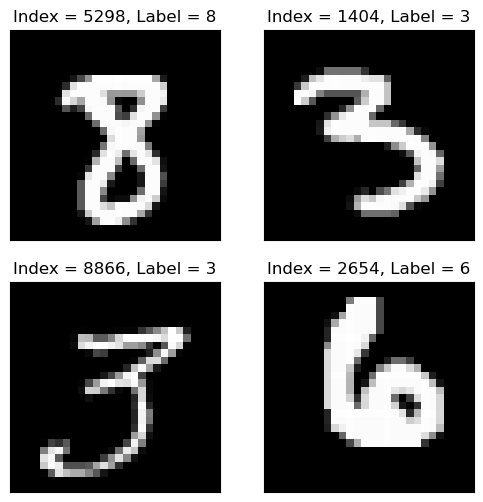

In [27]:
hF = PlotMnistImages(mX, vY, numRows=2, numCols=2)

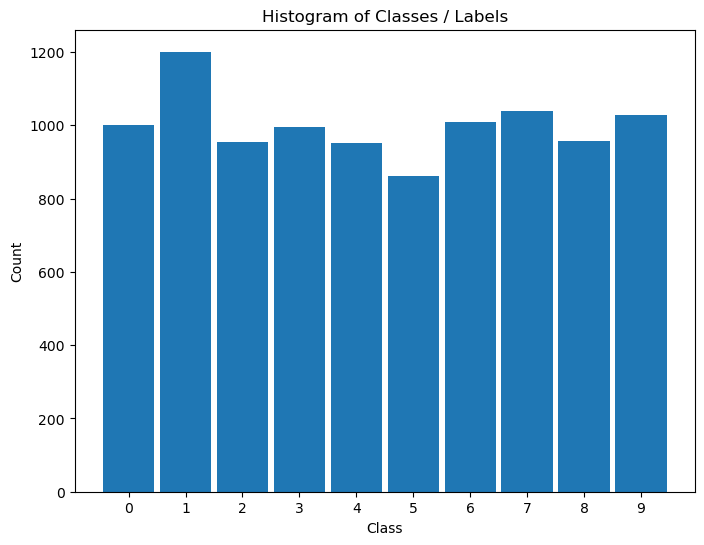

In [32]:
ha = PlotLabelsHistogram(vY)

In [38]:
# Train and Test split

mXTrain, mXTest, vYTrain, vYTest = train_test_split(mX, vY, train_size=train_ratio, test_size=test_ratio, random_state=seedNum)
print(f'The train feature matrix shape: {mXTrain.shape}')
print(f'The test feature matrix shape: {mXTest.shape}')
print(f'The test label vector shape: {vYTrain.shape}')
print(f'The train label vector shape: {vYTest.shape}')


The train feature matrix shape: (5500, 784)
The test feature matrix shape: (4500, 784)
The test label vector shape: (5500,)
The train label vector shape: (4500,)


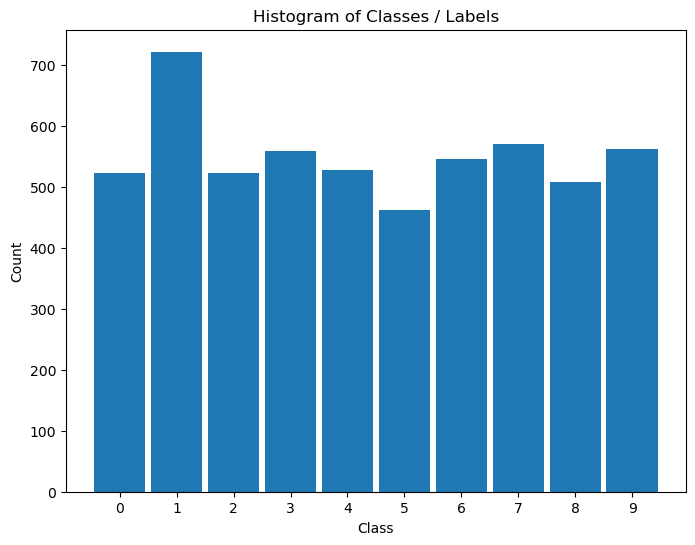

In [40]:
hA = PlotLabelsHistogram(vYTrain)

In [41]:
# train KNN model
K = 1
oKnnCls = KNeighborsClassifier(n_neighbors=K)
oKnnCls = oKnnCls.fit(mXTrain, vYTrain)

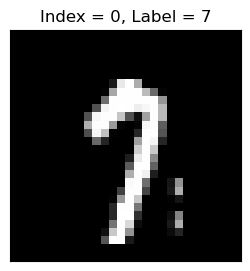

In [76]:
# Prediction on the Train Test

rndIdx = np.random.randint(mXTrain.shape[0])
yPred = oKnnCls.predict(np.atleast_2d(mXTrain[rndIdx, :]))
hF = PlotMnistImages(np.atleast_2d(mXTrain[rndIdx, :]), yPred, 1)


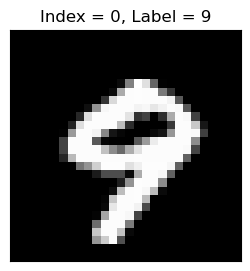

In [220]:
# Prediction on test set

rndIdx = np.random.randint(mXTest.shape[0])
yPred = oKnnCls.predict(np.atleast_2d(mX[rndIdx, :]))
hF = PlotMnistImages(np.atleast_2d(mX[rndIdx, :]), yPred, 1)

In [172]:
vYY = oKnnCls.predict(mXTest)
np.mean(vYTest == vYY)

np.float64(0.9342222222222222)

In [225]:
vYTrainPred = oKnnCls.predict(mXTrain)
vYTestPred = oKnnCls.predict(mXTest)

trainAcc = oKnnCls.score(mXTrain, vYTrain)
testAcc = oKnnCls.score(mXTest, vYTest)
testAcc

0.9342222222222222

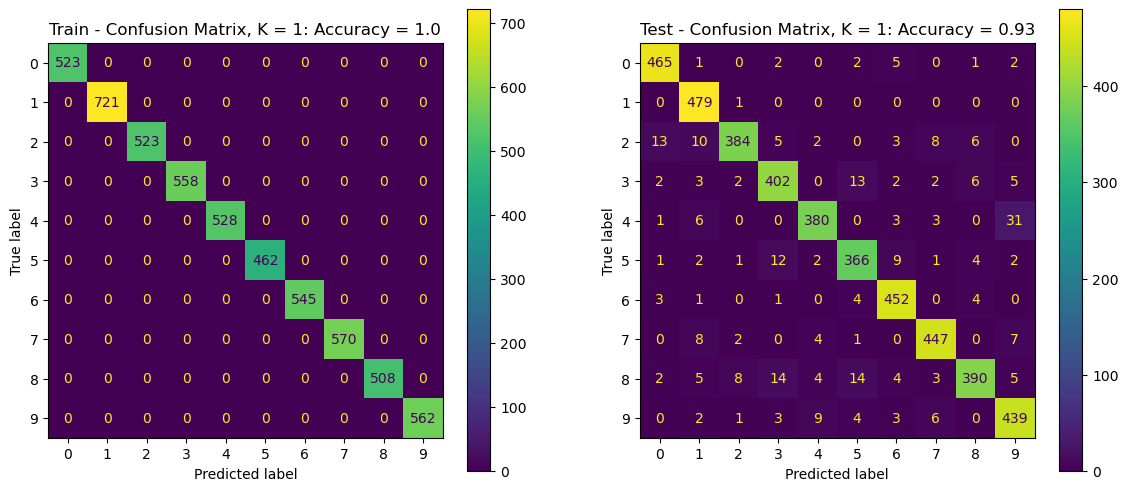

In [226]:
hF, hA = plt.subplots(nrows=1, ncols=2, figsize= (14, 6))

# Arranging data for the plot function
lConfMatData = [
    {
        'vY': vYTrain,
        'vYPred': vYTrainPred,
        'hA': hA[0],
        'dScore': {'Accuracy': trainAcc},
        'titleStr': f'Train - Confusion Matrix, K = {K}'
    },
    {
    'vY': vYTest,
    'vYPred': vYTestPred,
    'hA': hA[1],
    'dScore': {'Accuracy': testAcc},
    'titleStr': f'Test - Confusion Matrix, K = {K}'}]

for ii in range(2):
    PlotConfusionMatrix(**lConfMatData[ii])


In [228]:
KFold(10, shuffle=True)

KFold(n_splits=10, random_state=None, shuffle=True)

In [237]:
# Cross Validation & Predict
numFold = 10

vYTrainPred = cross_val_predict(KNeighborsClassifier(n_neighbors=K), mXTrain, vYTrain, cv = KFold(numFold, shuffle=True))
train_Acc = np.mean(vYTrainPred == vYTrain)
train_Acc

np.float64(0.9343636363636364)

In [238]:
# Cross Validation & Predict
numFold = 10

vYTrainPred = cross_val_predict(KNeighborsClassifier(n_neighbors=K), mXTrain, vYTrain, cv = StratifiedKFold(numFold, shuffle=True))
train_Acc = np.mean(vYTrainPred == vYTrain)
train_Acc

np.float64(0.9327272727272727)

In [242]:
numFold = 10
lK = list(range(1, 13, 2))
numK = len(lK)

lAcc = [None] * numK

for ii, K in enumerate(lK):
    vYTrainPred = cross_val_predict(KNeighborsClassifier(n_neighbors=K), mX, vY, cv = StratifiedKFold(numFold, shuffle=True))
    lAcc[ii] = np.mean(vYTrainPred == vY)


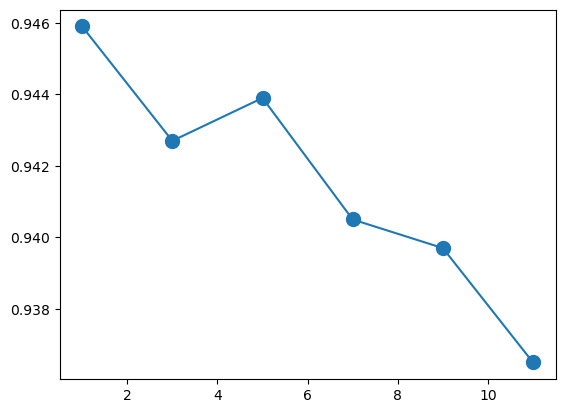

In [243]:
hF, hA = plt.subplots()
hA.plot(lK, lAcc)
hA.scatter(lK, lAcc, s=100)
plt.show()